In [1]:
import pandas as pd

from src.VideoIngestor import augment_dataset
from pathlib import Path
from utils.plot import plotTrainResults

from utils.constants import BASELINE_CONFIG
baseline_train = BASELINE_CONFIG

In [2]:
df_p1 = pd.read_csv(Path("data/unified_data_baseline.csv"))

histology_freqs = df_p1["histology"].value_counts()

print(histology_freqs)

histology
Adenoma                     1894
Sessile_serrated_adenoma     839
Hyperplastic                 399
Adenocarcinoma               120
Name: count, dtype: int64


In [3]:
phase2 = False

if phase2:
    augment_dataset(r"utils/models/Kvasir_yolov8m.pt")

In [4]:
phase2_csv_dir = Path('data/phase2/data_phase2_v2.csv')

histology_freqs = pd.read_csv(phase2_csv_dir)["histology"].value_counts()

print(histology_freqs)

histology
Adenoma                     3504
Sessile_serrated_adenoma    3024
Hyperplastic                2099
Adenocarcinoma               919
Name: count, dtype: int64


Cargando modelo guardado desde: C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase2_experiment_v2\best_baseline_model.pth


c:\Users\luis\Documents\TFG - Data-Centric AI\utils\plot.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(best_model_weights_path, map_location=device)


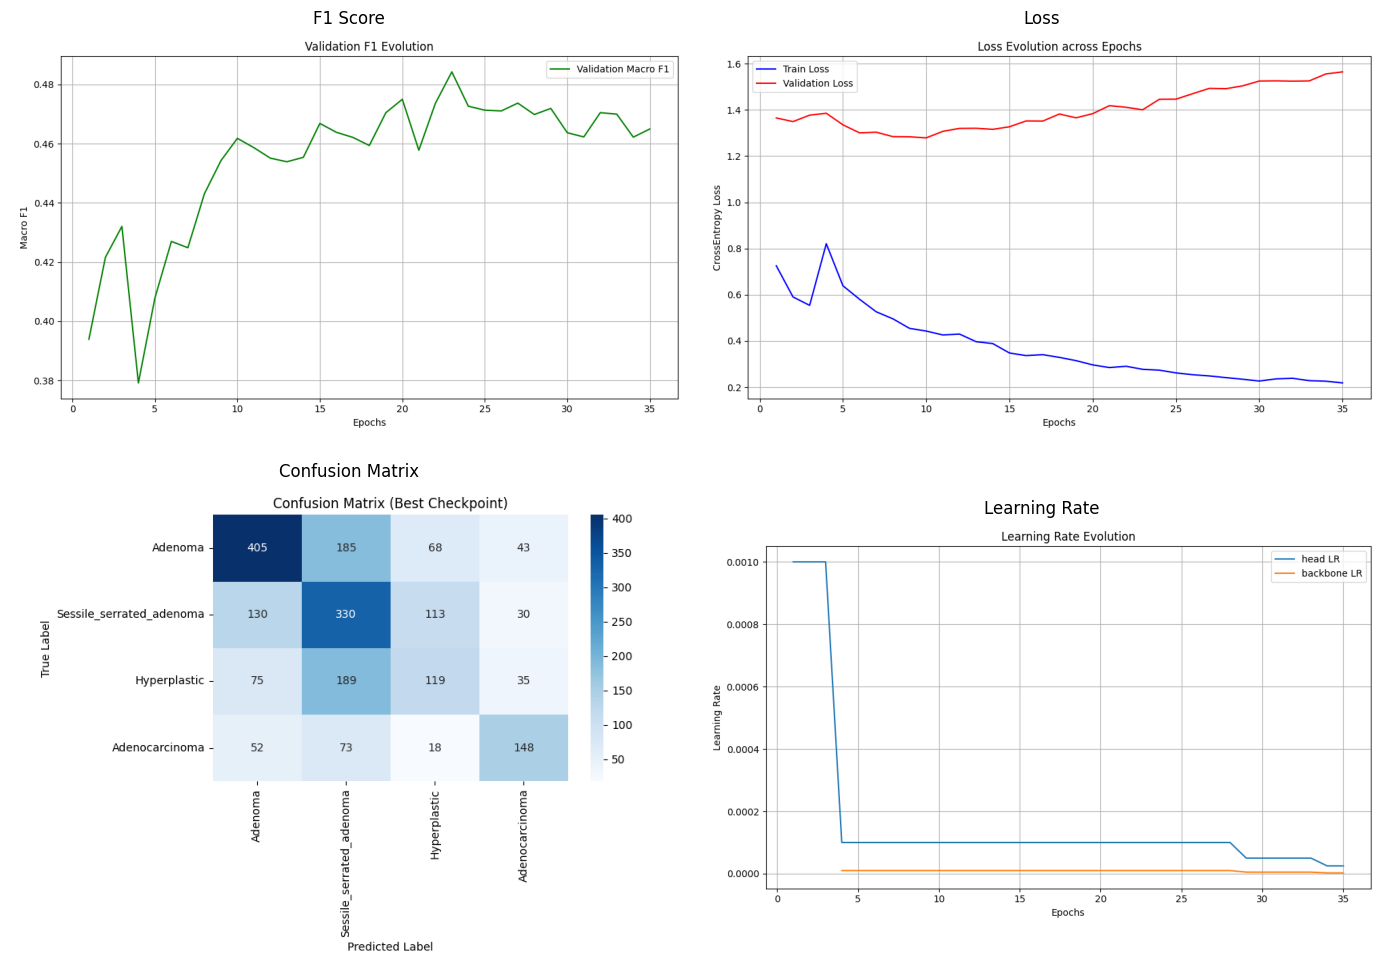

=== GLOBAL METRICS ===
Accuracy:          0.4978
Balanced Accuracy: 0.4796
Macro F1:          0.4843
Weighted F1:       0.4956

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.6118    0.5777    0.5943       701
Sessile_serrated_adenoma     0.4247    0.5473    0.4783       603
            Hyperplastic     0.3742    0.2847    0.3234       418
          Adenocarcinoma     0.5781    0.5086    0.5411       291

                accuracy                         0.4978      2013
               macro avg     0.4972    0.4796    0.4843      2013
            weighted avg     0.5015    0.4978    0.4956      2013



In [5]:
baseline_train.random_state = 42

phase2_img_dir = Path('phase2/framesv2')
phase2_csv_dir = Path('phase2/data_phase2_v2.csv')
phase2_dir = Path('phase2_experiment_v2')

plotTrainResults(phase_csv_dir=phase2_csv_dir, phase_img_dir=phase2_img_dir, results_dir=phase2_dir, train=baseline_train)